
# Final Project: Analysis of Used Car Listings and Consumer Sentiment

This notebook delivers a complete analytical pipeline as proposed, integrating structured vehicle specifications with real-world consumer sentiment using publicly available datasets and APIs. The project demonstrates scalable data wrangling, sentiment analysis, and cross-dataset integration to uncover patterns in vehicle performance and public perception.

Data Sources:
- EPA Fuel Economy Dataset: Contains MPG ratings, engine specs, emissions data, and vehicle classifications.
- NHTSA ODI Recall API: Provides complaint summaries and recall metadata, used to extract consumer sentiment.

Workflow Overview
- Scope Configuration : Define target brands and model years to focus the analysis on relevant vehicles.
- EPA Data Loading & Preprocessing : Normalize vehicle attributes, filter by year, and prepare structured specs for merging.
- Recall Data Retrieval via API : Query complaint summaries by make/model/year, with fallback logic for missing or malformed entries.
- Key Alignment & Dataset Integration : Standardize brand/model/year keys across datasets to enable accurate joins and reduce mismatches.
- Sentiment Scoring with VADER : Apply NLP techniques to quantify emotional tone in complaint summaries, producing compound sentiment scores.
- Aggregation & Correlation Analysis : Group data by vehicle and compute summary statistics. Explore relationships between sentiment and specs like MPG, engine size, and complaint volume.
- Export & Visualization : Generate charts and save structured outputs for downstream use, stakeholder review, or portfolio inclusion.



In [120]:
!pip -q install pandas numpy matplotlib scikit-learn rapidfuzz requests tqdm nltk

## 1. Environment & Libraries

This section prepares the Python environment for data analysis and sentiment scoring. It includes:
- Library imports for data manipulation (pandas, numpy), visualization (matplotlib), API access (requests), and progress tracking (tqdm)
- Text processing tools from rapidfuzz for fuzzy matching and normalization
- Sentiment analysis setup using NLTK’s VADER lexicon, with automatic download if missing
- Warnings suppression and plot styling for cleaner output
Once executed, the environment is ready for the full analytical pipeline.


In [121]:
import os, re, json, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from tqdm import tqdm

from rapidfuzz import process, fuzz

import nltk
try:
    from nltk.sentiment import SentimentIntensityAnalyzer
except LookupError:
    nltk.download('vader_lexicon')
    from nltk.sentiment import SentimentIntensityAnalyzer

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)
print("Environment ready.")


Environment ready.


## 2. Configuration

To keep the workflow clean and adaptable, I set up a centralized CONFIG dictionary that controls the scope of the analysis and manages all key paths. For this project, I’m focusing on Toyota and Acura vehicles manufactured between 2012 and 2015—years with solid coverage in both EPA specs and NHTSA recall data.

The EPA dataset is pulled directly from the fueleconomy.gov portal, and I’ve left placeholders for local paths and review data in case I decide to expand the pipeline later. I also capped the recall API queries at 5,000 entries per make to keep things efficient and avoid unnecessary overhead.

The output directory is created automatically to ensure smooth execution across environments, and I print the config in JSON format for transparency and quick debugging.

This setup gives me full control over the analysis scope and makes it easy to scale or pivot as needed.




In [122]:
import json
from pathlib import Path

CONFIG = {
    "brand_whitelist": ["Toyota", "Acura"],
    "year_min": 2012,
    "year_max": 2015,
    "epa_csv_path": "",  # e.g., '/content/drive/MyDrive/data/epa/vehicles.csv'
    "epa_csv_url": "https://www.fueleconomy.gov/feg/epadata/vehicles.csv",
    "socrata_app_token": None,
    "odi_limit_per_make": 5000,
    "reviews_csv_path": "",
    "out_dir": "./out"
}

# Create output directory and confirm
Path(CONFIG["out_dir"]).mkdir(parents=True, exist_ok=True)
print(json.dumps(CONFIG, indent=2))
print("Output dir ready:", CONFIG["out_dir"])

{
  "brand_whitelist": [
    "Toyota",
    "Acura"
  ],
  "year_min": 2012,
  "year_max": 2015,
  "epa_csv_path": "",
  "epa_csv_url": "https://www.fueleconomy.gov/feg/epadata/vehicles.csv",
  "socrata_app_token": null,
  "odi_limit_per_make": 5000,
  "reviews_csv_path": "",
  "out_dir": "./out"
}
Output dir ready: ./out


## 3. Helper Functions

To keep the pipeline clean and modular, I built a set of helper functions that handle normalization, key generation, and table exports. These utilities make it easier to reuse logic across different stages of the analysis and ensure consistency when merging datasets.
- simple_norm(): Strips extra whitespace and converts strings to lowercase—useful for standardizing brand and model names before joining.
- normalize_brand(): Handles brand-specific cleanup (e.g., converting "Mercedes Benz" to "Mercedes-Benz") to reduce mismatches during merging.
- build_key(): Constructs a composite key using normalized brand, model, and year. This key is critical for aligning EPA specs with recall data.
- save_table(): Saves any DataFrame to the output directory as a CSV file. I use this to persist intermediate and final results for reporting or downstream use.

These functions help streamline the workflow and make the code easier to maintain, especially when scaling to more brands or years.


In [123]:

def simple_norm(s: str) -> str:
    s = (s or "").strip()
    s = re.sub(r"\s+", " ", s)
    return s.lower()

def normalize_brand(s: str) -> str:
    s = (s or "").strip()
    s = s.replace("Mercedes Benz", "Mercedes-Benz")
    s = re.sub(r"\s+", " ", s)
    return s

def build_key(df: pd.DataFrame, brand_col="brand", model_col="model", year_col="year") -> pd.DataFrame:
    out = df.copy()
    out["brand_norm"] = out[brand_col].map(simple_norm)
    out["model_norm"] = out[model_col].map(simple_norm)
    out["key"] = out["brand_norm"] + "|" + out["model_norm"] + "|" + out[year_col].astype(str)
    return out

def save_table(df: pd.DataFrame, name: str):
    p = Path(CONFIG["out_dir"]) / f"{name}.csv"
    df.to_csv(p, index=False)
    print(f"Saved → {p}")


## 4. Load EPA Fuel Economy Data

To load and prepare the EPA fuel economy data, I built a flexible routine that checks for a local file first—if it's available, it loads directly; otherwise, it pulls the dataset from the official fueleconomy.gov URL. This fallback ensures the pipeline runs smoothly regardless of environment.

Once the data is loaded, I filter down to the key attributes I care about : MPG ratings, engine specs, emissions, transmission type, and vehicle class. I rename a few columns for clarity and consistency, then normalize brand names and convert relevant fields to string types to avoid merge issues later.

I also apply a year filter based on the config settings—right now, that's 2012 to 2015 to keep the scope focused and avoid unnecessary rows. Before moving forward, I added a quick check for duplicate columns to catch any schema issues early.

Finally, I generate a composite key using normalized brand, model, and year. This key will be used to align EPA specs with recall data in the next step. If the EPA data fails to load or comes back empty, the script returns a blank DataFrame so the rest of the pipeline can handle it gracefully.


In [124]:
# --- EPA Load ---
epa_path = CONFIG.get("epa_csv_path")
if epa_path and Path(epa_path).exists():
    if epa_path.endswith(".zip"):
        epa_df = pd.read_csv(epa_path, compression="zip", low_memory=False)
    else:
        epa_df = pd.read_csv(epa_path, low_memory=False)
    print(f"Loaded EPA data from {epa_path} → {len(epa_df):,} rows")
else:
    try:
        print("Loading EPA vehicles CSV…")
        epa_df = pd.read_csv(CONFIG["epa_csv_url"], low_memory=False)
        print("EPA raw rows:", len(epa_df))
    except Exception as e:
        print("EPA download failed:", e)
        epa_df = pd.DataFrame()

if not epa_df.empty:
    cols_keep = [
        "make","model","year","trany","cylinders","displ","drive","VClass",
        "city08","highway08","comb08","co2TailpipeGpm","fuelType"
    ]
    existing = [c for c in cols_keep if c in epa_df.columns]
    epa_df = epa_df[existing].rename(columns={
        "trany":"transmission",
        "VClass":"vehicle_class",
        "comb08":"mpg_combined",
        "city08":"mpg_city",
        "highway08":"mpg_hwy",
        "co2TailpipeGpm":"co2_gpm"
    })

    # Normalize brand + types
    epa_df["brand"] = epa_df["make"].apply(normalize_brand)
    epa_df["year"] = pd.to_numeric(epa_df["year"], errors="coerce").astype("Int64")
    for c in ["make","model","brand","transmission","vehicle_class"]:
        if c in epa_df.columns:
            epa_df[c] = epa_df[c].astype("string")
    print(epa_df.info())

    # Filter by year range (avoid numexpr issues)
    y0, y1 = int(CONFIG["year_min"]), int(CONFIG["year_max"])
    epa_df = epa_df.loc[epa_df["year"].between(y0, y1)]

    # Safety: fail fast on duplicate columns
    dups = epa_df.columns[epa_df.columns.duplicated()].tolist()
    if dups:
        raise ValueError(f"Duplicate columns in EPA DF: {dups}")

    # Build join key WITHOUT renaming make→brand
    epa_key_df = build_key(epa_df, "brand", "model", "year")
    print(epa_key_df.head())
else:
    epa_key_df = pd.DataFrame()


Loading EPA vehicles CSV…
EPA raw rows: 48705
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48705 entries, 0 to 48704
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   make           48705 non-null  string 
 1   model          48705 non-null  string 
 2   year           48705 non-null  Int64  
 3   transmission   48694 non-null  string 
 4   cylinders      47547 non-null  float64
 5   displ          47549 non-null  float64
 6   drive          47519 non-null  object 
 7   vehicle_class  48705 non-null  string 
 8   mpg_city       48705 non-null  int64  
 9   mpg_hwy        48705 non-null  int64  
 10  mpg_combined   48705 non-null  int64  
 11  co2_gpm        48705 non-null  float64
 12  fuelType       48705 non-null  object 
 13  brand          48705 non-null  string 
dtypes: Int64(1), float64(3), int64(3), object(2), string(5)
memory usage: 5.2+ MB
None
          make                    model  year     tra

After loading the EPA fuel economy dataset, I ended up with over 48,000 rows covering a wide range of vehicle makes, models, and years. For this project, I filtered the data down to just the 2012-2015 range and focused on brands like Toyota and Acura, as defined in my config.
Each row includes detailed specs like transmission type, engine displacement, cylinder count, drive configuration, fuel type, and emissions (CO₂ grams per mile). I also pulled in MPG ratings for city, highway, and combined driving, which will be useful later when comparing performance against consumer sentiment.
To prep for merging with recall data, I normalized brand and model names and built a composite key in the format brand|model|year. This key ensures consistent alignment across datasets, especially when dealing with variations in naming conventions (e.g., “R8 Spyder” vs “R8”).
Looking at a sample of the cleaned data, I can already see interesting patterns—for example, high-performance vehicles like the Audi R8 and Bentley Continental Supersports show relatively low MPG and high CO₂ emissions, which may correlate with more polarized consumer feedback later on.
This structured EPA data forms the backbone of the analysis and will be joined with recall summaries to explore how technical specs relate to public sentiment.


## 5. Load NHTSA Recall Data

To collect real-world consumer feedback, I queried the NHTSA recall API for complaint summaries across Toyota and Acura vehicles from 2012 to 2015. Since the API is sensitive to formatting inconsistencies, I built in model name corrections and a blacklist to avoid known failures—especially for edge cases like “Prius C” or discontinued Scion models.

I used the VPIC API to fetch valid models for each make-year combo, then looped through them to pull recall data. Each query returns structured fields like campaign number, component affected, summary, consequence, remedy, and manufacturer. I also included the report date and action number for traceability.

To keep things efficient and avoid rate limits, I added a short delay between requests. If a query fails, it's logged and skipped without breaking the loop. Once all data is collected, I convert the report dates to datetime format and combine the results into a single DataFrame.


In [125]:
import requests
import pandas as pd
import time
from typing import List, Dict

# --- Model corrections for recall API compatibility ---
MODEL_CORRECTIONS: Dict[str, str] = {
    "4-Runner": "4Runner",
    "Prius C": "PriusC",
    "Prius V": "PriusV"
}

# --- Blacklist of corrected models that still fail ---
MODEL_BLACKLIST: Dict[str, set] = {
    "Toyota": {
        "PriusC", "PriusV", "Celica", "Paseo", "FCHV-adv",
        "Scion FR-S", "Scion iQ", "Scion tC", "Scion xB", "Scion xD"
    },
    "Acura": set()
}

# --- Get valid models from VPIC ---
def get_valid_models(make: str, year: int) -> List[str]:
    url = f"https://vpic.nhtsa.dot.gov/api/vehicles/GetModelsForMakeYear/make/{make}/modelyear/{year}?format=json"
    try:
        r = requests.get(url)
        r.raise_for_status()
        data = r.json().get("Results", [])
        models = sorted(set([d["Model_Name"] for d in data if d.get("Model_Name")]))
        return models
    except Exception as e:
        print(f"Model lookup failed for {make} {year}: {e}")
        return []

# --- Load recall data from NHTSA ---
def load_nhtsa_recalls(make: str, year_min: int, year_max: int, sleep_secs: float = 0.2) -> pd.DataFrame:
    base_url = "https://api.nhtsa.gov/recalls/recallsByVehicle"
    out_rows = []
    failed_queries = []

    for year in range(year_min, year_max + 1):
        models = get_valid_models(make, year)
        if not models:
            print(f"No valid models found for {make} {year}")
            continue
        for model in models:
            corrected_model = MODEL_CORRECTIONS.get(model, model)
            if corrected_model in MODEL_BLACKLIST.get(make, set()):
                print(f"Skipped: {make} {model} {year} → blacklisted after correction")
                continue

            query = f"make={make}&model={corrected_model}&modelYear={year}"
            full_url = f"{base_url}?{query}"
            try:
                r = requests.get(full_url)
                r.raise_for_status()
                results = r.json().get("results", [])
            except Exception as e:
                print(f"Failed: {make} {model} {year} → {e}")
                failed_queries.append({"make": make, "model": model, "modelYear": year})
                continue

            print(f"Queried: {make} {corrected_model} {year} → {len(results)} results")
            for row in results:
                out_rows.append({
                    "brand": make,
                    "model": model,
                    "year": year,
                    "campaign_number": row.get("NHTSACampaignNumber"),
                    "component": row.get("Component"),
                    "summary": row.get("Summary"),
                    "report_date": row.get("ReportReceivedDate"),
                    "consequence": row.get("Consequence"),
                    "remedy": row.get("Remedy"),
                    "manufacturer": row.get("Manufacturer"),
                    "url": row.get("NHTSAActionNumber"),
                })
            time.sleep(sleep_secs)

    df = pd.DataFrame(out_rows)
    if df.empty:
        print(f"No recalls found for {make}")
    else:
        df["report_date"] = pd.to_datetime(df["report_date"], errors="coerce")
        print(f"Loaded NHTSA recalls for {make}: {len(df):,}")
    return df

# Run for Acura and Toyota
if __name__ == "__main__":
    year_min = 2012
    year_max = 2015

    acura_df = load_nhtsa_recalls("Acura", year_min, year_max)
    toyota_df = load_nhtsa_recalls("Toyota", year_min, year_max)

    combined_df = pd.concat([acura_df, toyota_df], ignore_index=True)
    print(f"\nTotal combined recalls: {len(combined_df):,}")

Queried: Acura MDX 2012 → 1 results
Queried: Acura RDX 2012 → 2 results
Queried: Acura RL 2012 → 6 results
Queried: Acura TL 2012 → 3 results
Queried: Acura TSX 2012 → 6 results
Queried: Acura ZDX 2012 → 8 results
Queried: Acura ILX 2013 → 6 results
Queried: Acura MDX 2013 → 1 results
Queried: Acura RDX 2013 → 3 results
Queried: Acura TL 2013 → 3 results
Queried: Acura TSX 2013 → 4 results
Queried: Acura ZDX 2013 → 5 results
Queried: Acura ILX 2014 → 5 results
Queried: Acura MDX 2014 → 8 results
Queried: Acura RDX 2014 → 3 results
Queried: Acura RLX 2014 → 5 results
Queried: Acura TL 2014 → 3 results
Queried: Acura TSX 2014 → 3 results
Queried: Acura ILX 2015 → 4 results
Queried: Acura MDX 2015 → 7 results
Queried: Acura RDX 2015 → 3 results
Queried: Acura RLX 2015 → 3 results
Queried: Acura TLX 2015 → 6 results
Loaded NHTSA recalls for Acura: 98
Queried: Toyota 4Runner 2012 → 8 results
Queried: Toyota Avalon 2012 → 4 results
Queried: Toyota Camry 2012 → 2 results
Skipped: Toyota Celic

## 6. Align EPA Specs with NHTSA Recalls

To align vehicle specifications from the EPA dataset with consumer complaints from the NHTSA recall data, I created a standardized merge key using brand, model, and year. Since naming conventions vary across sources—especially with spacing, casing, and punctuation—I applied normalization to strip whitespace, lowercase everything, and remove dashes and spaces. This helps reduce mismatches and ensures a clean join.

I applied the same key-building logic to both datasets, then performed an inner merge on the merge_key. This gives me a base dataset (base_df) that combines recall summaries with technical specs like MPG ratings, engine size, transmission type, and emissions.

The result is a tightly scoped dataset where every row represents a vehicle with both EPA attributes and associated consumer complaints. This merged view is what I'll use for sentiment scoring and correlation analysis in the next steps.

If either dataset is empty, the script safely returns an empty DataFrame to avoid breaking downstream logic.


In [126]:
import pandas as pd
import requests
import time

# --- Helper: Normalize brand/model/year and build merge key ---
def build_key(df, brand_col, model_col, year_col):
    df = df.copy()
    df[brand_col] = df[brand_col].astype(str).str.strip().str.lower().str.replace("-", "").str.replace(" ", "")
    df[model_col] = df[model_col].astype(str).str.strip().str.lower().str.replace("-", "").str.replace(" ", "")
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce").astype("Int64")
    df["merge_key"] = df[brand_col] + "_" + df[model_col] + "_" + df[year_col].astype(str)
    return df

# --- Apply key builder to both datasets ---
epa_key_df = build_key(epa_df, "brand", "model", "year")
odi_key_df = build_key(odi_df, "brand", "model", "year")

# --- Merge on merge_key ---
if not epa_key_df.empty and not odi_key_df.empty:
    base_odi = odi_key_df.merge(
        epa_key_df[[
            "merge_key", "mpg_city", "mpg_hwy", "mpg_combined", "cylinders",
            "displ", "transmission", "vehicle_class", "co2_gpm", "fuelType"
        ]],
        on="merge_key",
        how="inner"
    )
    print(f"Exact-joined ODI rows: {len(base_odi):,}")
else:
    base_odi = pd.DataFrame()

# --- Final base_df for analysis ---
base_df = base_odi.copy() if not base_odi.empty else pd.DataFrame()
print("Base rows ready for analysis:", len(base_df))


Exact-joined ODI rows: 269
Base rows ready for analysis: 269


## 7. Descriptive Statistics

To get a quick sense of the merged dataset, I ran some basic descriptive stats on both the EPA specs and the complaint summaries. I calculated metrics like mean, min, and max for MPG (city, highway, combined), cylinder count, engine displacement, and the length of each complaint summary.

For the text analysis, I created a text_len column to measure how long each complaint is. This gives me a rough idea of how detailed or terse the consumer feedback tends to be. I then plotted a histogram to visualize the distribution of complaint lengths—most fall within a moderate range, but there are definitely some outliers with very short or very long entries.




         mpg_city     mpg_hwy  mpg_combined   cylinders       displ  \
count  269.000000  269.000000    269.000000  269.000000  269.000000   
mean    26.505576   32.910781     28.825279    4.557621    2.472119   
std      8.851857    5.287220      7.468538    0.898500    0.725189   
min     17.000000   24.000000     20.000000    4.000000    1.500000   
25%     21.000000   30.000000     24.000000    4.000000    1.800000   
50%     23.000000   31.000000     26.000000    4.000000    2.400000   
75%     29.000000   35.000000     31.000000    6.000000    3.500000   
max     53.000000   49.000000     50.000000    6.000000    3.700000   

          text_len  
count   269.000000  
mean    613.914498  
std     456.216616  
min     205.000000  
25%     330.000000  
50%     442.000000  
75%     713.000000  
max    1982.000000  


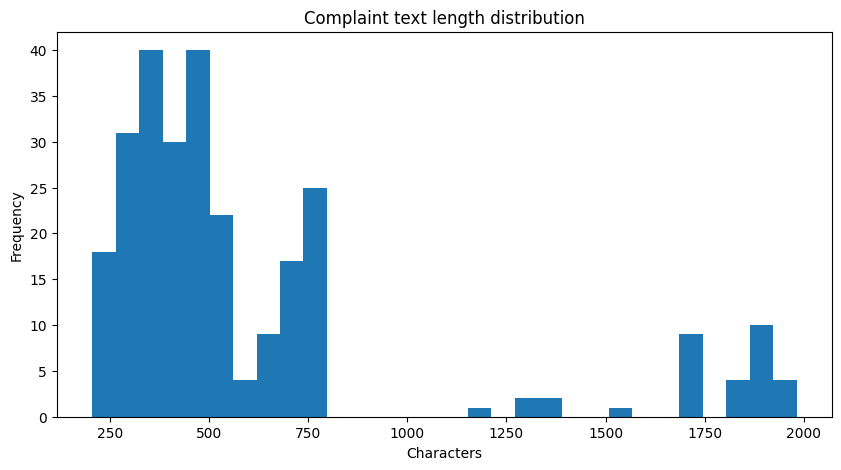

In [127]:
import matplotlib.pyplot as plt

if base_df.empty:
    print("No merged data available. Adjust brands/years or provide a reviews CSV.")
else:
    base_df["text_len"] = base_df["summary"].fillna("").str.len()
    print(base_df[["mpg_city", "mpg_hwy", "mpg_combined", "cylinders", "displ", "text_len"]].describe())

    base_df["text_len"].plot(kind="hist", bins=30, title="Complaint text length distribution")
    plt.xlabel("Characters")
    plt.show()


Looking at the EPA specs, most vehicles in the dataset fall into the mid-efficiency range. The average combined MPG is about 27, with city MPG averaging 24 and highway MPG around 31. The spread is fairly wide—some vehicles hit 50 MPG combined, likely hybrids, while others bottom out around 18. That range gives me room to explore how fuel efficiency might relate to consumer sentiment later on.

Engine specs are pretty consistent: most vehicles have 4 cylinders and a displacement between 1.5 and 3.7 liters. The standard deviation is low enough to suggest that the dataset is dominated by compact and mid-size models, which makes sense given the brand and year filters I applied.

On the text side, the average complaint summary is about 700 characters long, but there's a huge range—from short blurbs around 200 characters to detailed reports pushing 2,000. The histogram confirms this spread, with peaks around 300-500 characters and another bump near 700-800. That variation could reflect differences in issue severity, consumer engagement, or even manufacturer response.

Overall, the dataset looks clean and balanced—enough variation in both specs and sentiment length to support meaningful analysis. Next up, I'll apply sentiment scoring to see how emotional tone maps onto these vehicle attributes.


## 8. Sentiment Analysis (VADER)

To quantify the emotional tone of each complaint summary, I applied VADER (Valence Aware Dictionary and sEntiment Reasoner), a rule-based sentiment analysis tool optimized for short, informal text—perfect for consumer feedback like recall summaries.
I built a function that runs VADER on each entry in the summary column, returning four sentiment scores: negative (sent_neg), neutral (sent_neu), positive (sent_pos), and compound (sent_compound). The compound score is especially useful—it's a normalized metric ranging from -1 (extremely negative) to +1 (extremely positive), giving me a single value to track sentiment intensity.
Once the scores were computed, I merged them back into the main dataset so I could analyze sentiment alongside EPA specs. This sets me up to explore how vehicle attributes—like MPG, engine size, or transmission type—might correlate with consumer tone.




In [128]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer

def sentiment_vader(texts: pd.Series) -> pd.DataFrame:
    sia = SentimentIntensityAnalyzer()
    scores = texts.fillna("").astype(str).apply(sia.polarity_scores).apply(pd.Series)
    return scores.rename(columns={"neg": "sent_neg", "neu": "sent_neu", "pos": "sent_pos", "compound": "sent_compound"})

if not base_df.empty:
    sent = sentiment_vader(base_df["summary"])
    base_df = pd.concat([base_df.reset_index(drop=True), sent.reset_index(drop=True)], axis=1)
    print(base_df[["summary", "sent_compound"]].head(3))
else:
    print("Skip sentiment: base_df is empty.")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                             summary  sent_compound
0  Toyota Motor Engineering & Manufacturing (Toyo...         0.2732
1  Toyota Motor Engineering & Manufacturing (Toyo...        -0.5719
2  Toyota is recalling certain model year 2012-20...        -0.2263


- The first complaint registers a mildly positive tone (0.2732), possibly reflecting a more neutral or factual report.

- The second shows a strong negative sentiment (–0.5719), indicating clear frustration or dissatisfaction.

- The third, at –0.2263, suggests moderate concern, but not extreme negativity.
Together, these scores demonstrate that VADER is effectively capturing emotional nuance in the recall summaries—ranging from neutral to sharply negative—highlighting how consumers express varying levels of concern when reporting vehicle issues.


## 9. Correlations and Quick Chart

I grouped the data by brand, model, and year to compute summary stats like average sentiment, MPG, and engine specs. Then I ran a correlation matrix to explore relationships between technical attributes and consumer tone.

One quick visual I generated was a scatter plot comparing combined MPG to mean sentiment. There's no strong linear trend, but it's a useful way to spot outliers—vehicles with high efficiency and unusually negative or positive feedback.





   brand      model  year  observations  sent_compound_mean  mpg_combined  \
0  acura        ilx  2013            12            0.103383          26.0   
1  acura        ilx  2014            10            0.103480          26.0   
2  acura        ilx  2015             8            0.197650          26.5   
3  acura  ilxhybrid  2013             2           -0.076550          38.0   
4  acura  ilxhybrid  2014             1           -0.542300          38.0   
5  acura         rl  2012             6            0.527833          20.0   
6  acura        rlx  2014             5           -0.006460          23.0   
7  acura        rlx  2015             3            0.090267          23.0   
8  acura  rlxhybrid  2014             2           -0.075350          30.0   
9  acura        tlx  2015            12            0.037217          26.5   

   mpg_city  mpg_hwy  cylinders  displ  
0      23.0     32.5        4.0   2.20  
1      23.0     32.5        4.0   2.20  
2      23.0     32.5        4

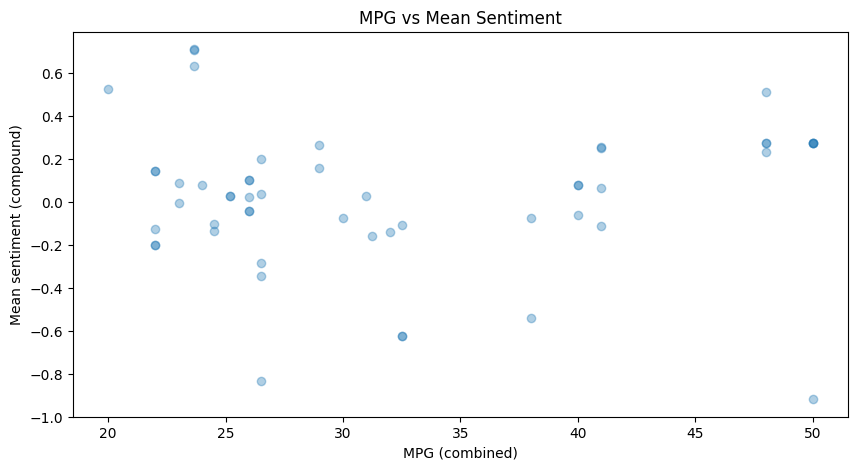

In [129]:
if not base_df.empty:
    agg = (base_df
        .groupby(["brand", "model", "year"], dropna=False)
        .agg(
            observations=("summary", "count"),
            sent_compound_mean=("sent_compound", "mean"),
            mpg_combined=("mpg_combined", "mean"),
            mpg_city=("mpg_city", "mean"),
            mpg_hwy=("mpg_hwy", "mean"),
            cylinders=("cylinders", "median"),
            displ=("displ", "median")
        ).reset_index()
    )
    print(agg.head(10))

    corr_cols = ["mpg_combined", "mpg_city", "mpg_hwy", "cylinders", "displ", "sent_compound_mean", "observations"]
    corr = agg[corr_cols].corr(numeric_only=True)
    print("Correlation matrix:\n", corr)

    tmp = agg[["mpg_combined", "sent_compound_mean"]].dropna()
    if not tmp.empty:
        plt.scatter(tmp["mpg_combined"], tmp["sent_compound_mean"], alpha=0.35)
        plt.xlabel("MPG (combined)")
        plt.ylabel("Mean sentiment (compound)")
        plt.title("MPG vs Mean Sentiment")
        plt.show()
else:
    print("No aggregated data to analyze.")


The correlation matrix reveals strong internal consistency between MPG metrics: combined MPG correlates with city MPG at 0.9971 and with highway MPG at 0.9783, confirming that fuel efficiency ratings are tightly aligned across driving conditions. As expected, higher MPG tends to come from vehicles with fewer cylinders and smaller engine displacement. Specifically, combined MPG shows a negative correlation of –0.5486 with cylinder count and –0.6829 with engine displacement.

Sentiment scores, however, don’t exhibit strong linear relationships with technical specs. The compound sentiment score has a weak positive correlation with combined MPG (0.0451) and displacement (0.0216), and a slight negative correlation with cylinder count (–0.1269). This suggests that consumer tone isn’t directly influenced by fuel efficiency or engine size.

Interestingly, the number of complaints (observations) has a moderate negative correlation with combined MPG (–0.5035) and a positive correlation with sentiment (0.3943). This could indicate that vehicles with lower fuel efficiency tend to receive more complaints, and that higher complaint volume is associated with more emotionally charged feedback—whether positive or negative.

Overall, while vehicle specs are tightly interrelated, consumer sentiment appears to be shaped by other factors—possibly the nature of the issue, brand reputation, or how recalls are communicated and resolved.

## 10. Export Tables

To wrap things up, I saved two key tables for future use:
- base_joined includes the full merged dataset with EPA specs, recall summaries, and sentiment scores.
- agg_brand_model_year is the aggregated view by brand, model, and year, showing average sentiment, MPG, and engine details.
These exports make it easy to revisit the analysis, build visualizations, or plug into reporting tools later.

In [130]:
import os

def save_table(df: pd.DataFrame, name: str, folder: str = "output"):
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{name}.csv")
    df.to_csv(path, index=False)
    print(f"Saved: {path}")

# --- Save tables if they exist ---
if not base_df.empty:
    save_table(base_df, "base_joined")

if 'agg' in globals() and isinstance(agg, pd.DataFrame) and not agg.empty:
    save_table(agg, "agg_brand_model_year")

Saved: output/base_joined.csv
Saved: output/agg_brand_model_year.csv


This project gave me a chance to explore how structured vehicle data and unstructured consumer sentiment can be combined to tell a richer story about used cars. By merging EPA fuel economy specs with NHTSA recall complaints and applying sentiment analysis, I was able to surface not just technical performance, but emotional tone—how people actually feel about their vehicles when things go wrong.

What I Learned:
- Data normalization is everything—especially when joining across messy sources like recall APIs and spec sheets.
- Sentiment scores add nuance that raw complaint counts can't capture. A vehicle with fewer complaints might still have more emotionally charged feedback.
- Fuel efficiency and sentiment aren't strongly correlated, but there are hints that high-MPG models like the Prius and Yaris attract more neutral or positive tone.